In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cap = pd.read_csv('sp500_cap_weighted_returns.csv')
cap.head()

,date,0
0,1960-01-29,-0.067093
1,1960-02-29,0.017111
2,1960-03-31,-0.010623
3,1960-04-29,-0.013724
4,1960-05-31,0.037913


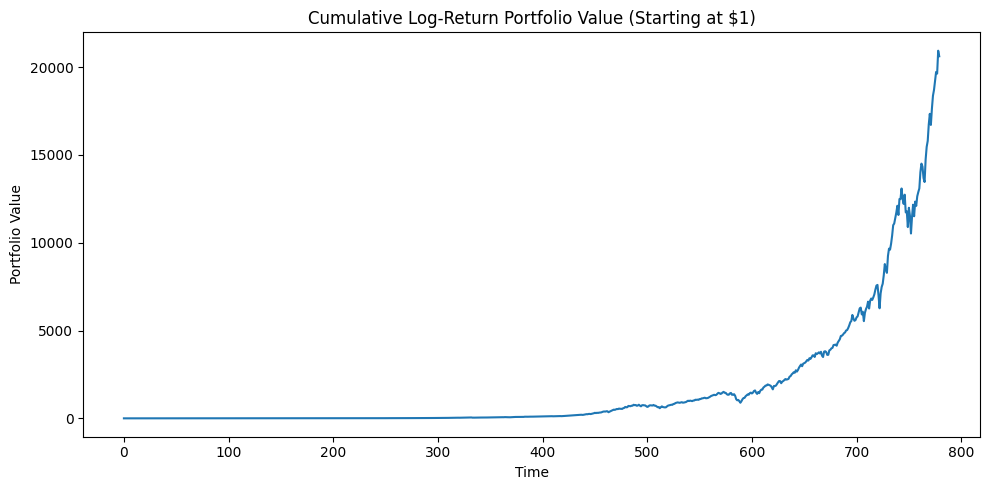

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your time-series
cap = pd.read_csv('sp500_cap_weighted_returns.csv')

# Identify the returns column (assumed to be the first numeric column)
returns_col = [c for c in cap.columns if cap[c].dtype != 'object'][0]
rets = cap[returns_col]

# Compute log returns
log_rets = np.log1p(rets)

# Compute cumulative log returns
cum_log_rets = log_rets.cumsum()

# Convert cumulative log returns into a $1 portfolio value
portfolio_value = np.exp(cum_log_rets)

# Plot
plt.figure(figsize=(10,5))
plt.plot(portfolio_value)
plt.title("Cumulative Log-Return Portfolio Value (Starting at $1)")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.tight_layout()
plt.show()


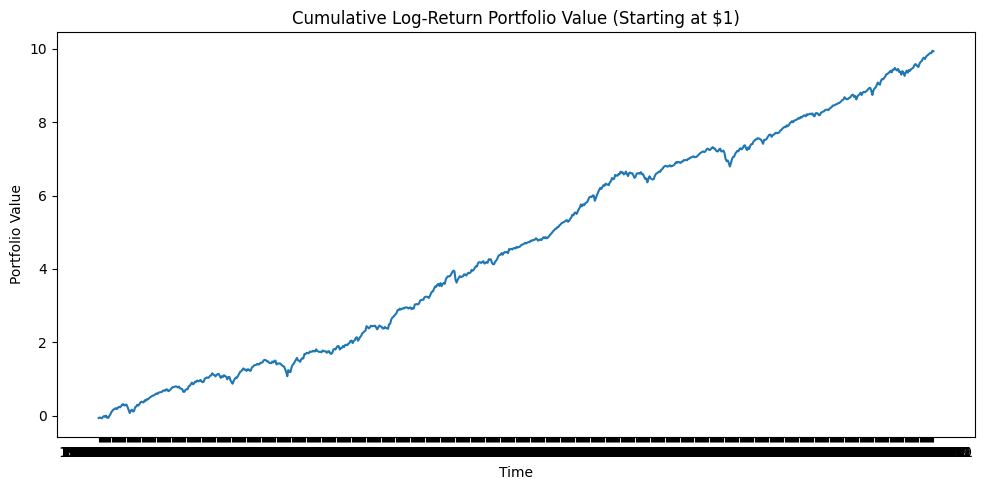

In [5]:
data = pd.read_csv("sp500_returns_with_tickers.csv", index_col="date")
cap_data = pd.read_csv("sp500_market_caps.csv", index_col="date")
cap_data_numeric = cap_data.apply(pd.to_numeric, errors='coerce')
cap_data_numeric = cap_data_numeric.fillna(0)
weight_data = cap_data_numeric.div(cap_data_numeric.sum(axis=1), axis=0)
data = data[weight_data.columns]

data_numeric = data.apply(pd.to_numeric, errors='coerce').fillna(0)

# Now compute returns:
sp500_returns = (data_numeric * weight_data).sum(axis=1)

log_rets = np.log1p(sp500_returns)

# Compute cumulative log returns
cum_log_rets = log_rets.cumsum()

# Convert cumulative log returns into a $1 portfolio value
#portfolio_value = np.exp(cum_log_rets)

# Plot
plt.figure(figsize=(10,5))
plt.plot(cum_log_rets)
plt.title("Cumulative Log-Return Portfolio Value (Starting at $1)")
plt.xlabel("Time")
plt.ylabel("Portfolio Value")
plt.tight_layout()
plt.show()